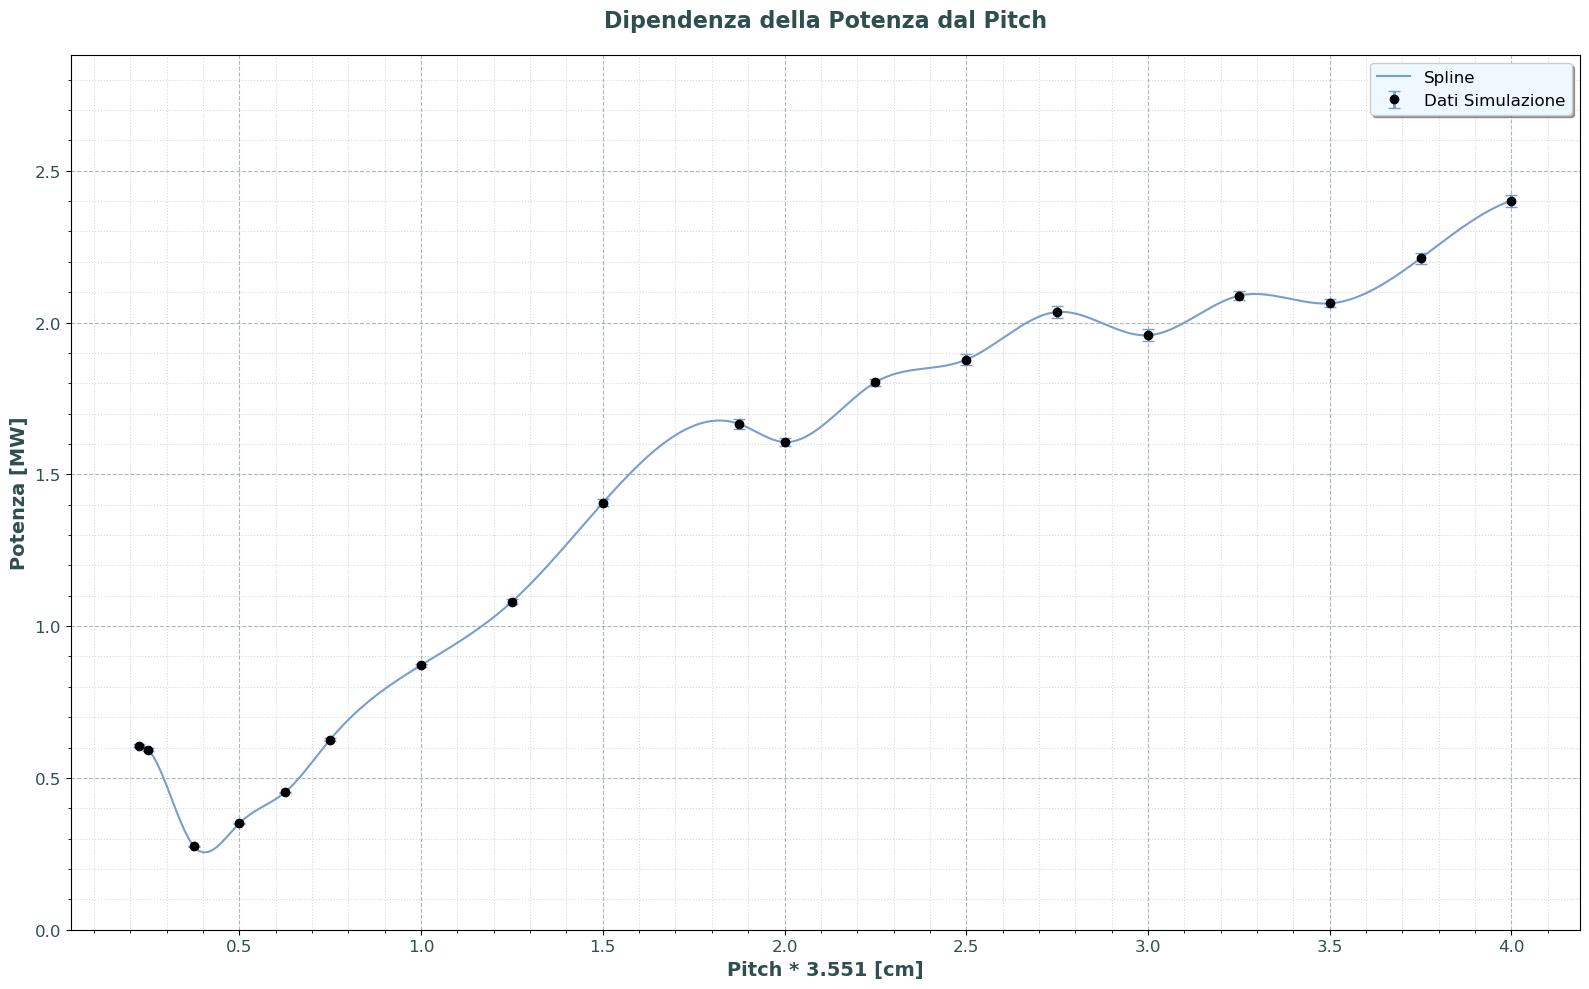

In [1]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import openmc

E_FISSION_J = 200.0 * 1e6 * 1.6022e-19  # Energia media per fissione [J]
S_INTENSITY = 2.02e17                   # Fotoni/s dal sincrotrone

def analizza_potenza():
    """Legge i file .h5, estrae media e deviazione standard delle fissioni, calcola potenza e incertezza."""
    # Aggiornato per leggere i file dal formato fornito
    file_list = glob.glob("fixed/statepoints/statepoint_pitch_*.h5")
    
    if not file_list:
        print("Nessun file statepoint trovato nella cartella corrente.")
        return pd.DataFrame()
        
    dati = []
    # Regex per estrarre il pitch dal nome file (es. 0_750 -> 0.750)
    pattern = re.compile(r"statepoint_pitch_([\d_]+)\.h5")

    for file_sp in file_list:
        filename = os.path.basename(file_sp)
        match = pattern.search(filename)
        if not match:
            continue
            
        pitch_str = match.group(1).replace('_', '.')
        pitch = float(pitch_str)
        
        with openmc.StatePoint(file_sp) as sp:
            try:
                tally = sp.get_tally(name='fission_tot')
                fission_mean = tally.mean.flatten()[0]
                fission_std = tally.std_dev.flatten()[0] # Estrazione errore statistico
            except KeyError:
                print(f"Attenzione: Tally 'fission_tot' non trovato in {file_sp}")
                continue
                
        # Calcolo Potenza e Incertezza [MW]
        potenza_MW = (fission_mean * S_INTENSITY * E_FISSION_J) / 1e6
        errore_MW = (fission_std * S_INTENSITY * E_FISSION_J) / 1e6
        
        dati.append({
            'Pitch': pitch,
            'Potenza_MW': potenza_MW,
            'Errore_MW': errore_MW
        })
        
    return pd.DataFrame(dati)

def plot_scatter_smooth_err(df):
    """Genera plot a dispersione Potenza vs Pitch con styling rigoroso."""
    if df.empty:
        return
        
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Ordinamento in base al Pitch
    df = df.sort_values(by='Pitch')
    x = df['Pitch'].values
    y = df['Potenza_MW'].values
    y_err = df['Errore_MW'].values
    
    # Plot dei punti centrali con barre di errore
    ax.errorbar(x, y, yerr=y_err, fmt='o', color='#000000', ecolor='#789DD1', 
                elinewidth=2, capsize=4, zorder=5, label='Dati Simulazione')
    
    # Interpolazione spline
    if len(x) >= 3:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)
        y_smooth = spline(x_smooth)
        ax.plot(x_smooth, y_smooth, zorder=4, color='#789DD1', label='Spline')
    else:
        ax.plot(x, y, zorder=4, color='#789DD1', label='Line')

    # Calcolo rigoroso media pesata su tutto il dataset
    pesi = 1.0 / (df['Errore_MW']**2)
    media_pesata = np.sum(df['Potenza_MW'] * pesi) / np.sum(pesi)

    chi_quadro = np.sum(((df['Potenza_MW'] - media_pesata)**2) / (df['Errore_MW']**2))
    chi_ridotto = chi_quadro / max(1, len(df) - 1)
    errore_media = 1.0 / np.sqrt(np.sum(pesi))

    # Se chi_ridotto > 1, i dati variano più dell'errore statistico
    if chi_ridotto > 1:
        errore_media = errore_media * np.sqrt(chi_ridotto)
    
    # Aggiunta retta orizzontale verde e banda di confidenza
    #ax.axhline(y=media_pesata, color='green', linestyle='-.', linewidth=2, 
    #           zorder=3, label=f'Media Pesata: {media_pesata:.3f} $\pm$ {errore_media:.3f} MW')
    #ax.axhspan(ymin=media_pesata - errore_media, ymax=media_pesata + errore_media, 
    #           color='green', alpha=0.2, zorder=2, label=r'Confidenza $1\sigma$')
            
    # Formattazione
    ax.set_title('Dipendenza della Potenza dal Pitch', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Pitch * 3.551 [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    
    # Griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda
    ax.legend(loc='best', frameon=True, shadow=True, 
              fontsize=12, facecolor='#F0F8FF')

    plt.ylim(0.0, df['Potenza_MW'].max() * 1.2)
    
    plt.tight_layout()
    plt.savefig('scatter_potenza_pitch.png', dpi=300)

# Esecuzione
df_potenza = analizza_potenza()
plot_scatter_smooth_err(df_potenza)

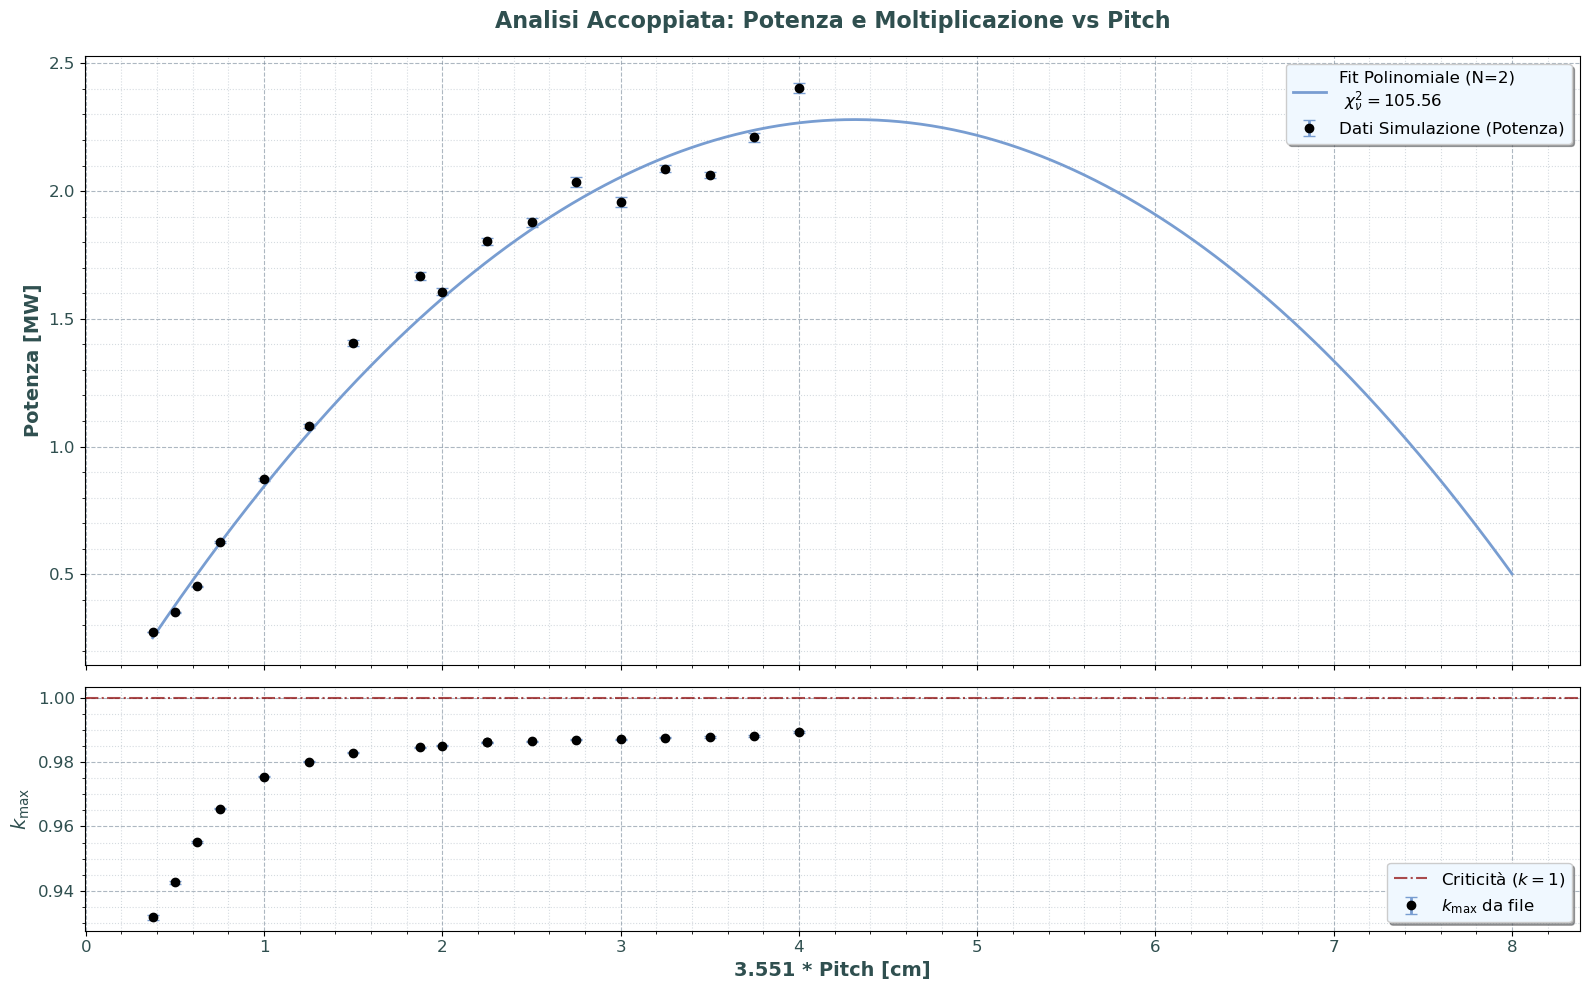

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def estrai_kmax(filepath):
    """Estrae Pitch, K_max e relativo errore dal file di testo grezzo."""
    dati = []
    try:
        with open(filepath, 'r') as f:
            testo = f.read()
            
        # Isolamento della parte numerica successiva all'intestazione
        if 'Compatibilità' in testo:
            testo = testo.split('Compatibilità')[-1]
            
        numeri = [float(x) for x in testo.split()]
        
        # Il file ha 12 valori per ogni record simulato
        for i in range(0, len(numeri), 12):
            if i + 8 < len(numeri):
                dati.append({
                    'Pitch': numeri[i+1],
                    'K_max': numeri[i+7],
                    'Errore_K': numeri[i+8]
                })
    except FileNotFoundError:
        print(f"File {filepath} non trovato.")
        
    return pd.DataFrame(dati)

def plot_potenza_e_kmax(df_potenza, file_txt, N=2):
    """
    Esegue il fit polinomiale pesato sulla potenza e lo confronta con 
    l'andamento del k_max in due pad sovrapposti.
    """
    if df_potenza.empty:
        return
        
    # Filtro spaziale: esclusione regime fortemente sottomoderato
    df_potenza = df_potenza[df_potenza['Pitch'] >= 0.370].copy().sort_values(by='Pitch')
    
    # Estrazione e filtro dati K_max
    df_kmax = estrai_kmax(file_txt)
    df_kmax = df_kmax[df_kmax['Pitch'] >= 0.370].copy().sort_values(by='Pitch')
    
    # --- CALCOLO FIT ---
    x_pow = df_potenza['Pitch'].values
    y_pow = df_potenza['Potenza_MW'].values
    err_pow = df_potenza['Errore_MW'].values
    err_pow = np.where(err_pow == 0, 1e-10, err_pow) # Previene divisioni per zero
    
    pesi = 1.0 / err_pow
    coeff = np.polyfit(x_pow, y_pow, N, w=pesi)
    poly = np.poly1d(coeff)
    
    x_fit = np.linspace(min(x_pow.min(), df_kmax['Pitch'].min()), 
                        2*max(x_pow.max(), df_kmax['Pitch'].max()), 500)
    y_fit = poly(x_fit)
    
    chi_quadro = np.sum(((y_pow - poly(x_pow)) / err_pow)**2)
    dof = len(x_pow) - (N + 1)
    chi_rid = chi_quadro / dof if dof > 0 else np.nan

    # --- CREAZIONE FIGURA ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2.5, 1]})
    
    # --- PAD SUPERIORE: POTENZA ---
    ax1.errorbar(x_pow, y_pow, yerr=err_pow, fmt='o', color='#000000', ecolor='#789DD1', 
                 elinewidth=2, capsize=4, zorder=5, label='Dati Simulazione (Potenza)')
    ax1.plot(x_fit, y_fit, zorder=4, color='#789DD1', linewidth=2, 
             label=f'Fit Polinomiale (N={N}) \n $\chi^2_\\nu = {chi_rid:.2f}$')
    
    ax1.set_title('Analisi Accoppiata: Potenza e Moltiplicazione vs Pitch', 
                  fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax1.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # --- PAD INFERIORE: K_MAX ---
    if not df_kmax.empty:
        ax2.errorbar(df_kmax['Pitch'], df_kmax['K_max'], yerr=df_kmax['Errore_K'], 
                     fmt='o', color='#000000', ecolor='#789DD1', 
                     elinewidth=2, capsize=4, zorder=5, label='$k_{\max}$ da file')
                     
        # Aggiunta asintoto di criticità per riferimento fisico
        ax2.axhline(y=1.0, color='#8B0000', linestyle='-.', linewidth=1.5, alpha=0.7, label='Criticità ($k=1$)')
        
    ax2.set_xlabel('3.551 * Pitch [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax2.set_ylabel('$k_{\max}$', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # --- FORMATTAZIONE CONDIVISA ---
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
        ax.minorticks_on()
        ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
        ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
        ax.legend(loc='best', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05) # Minimizza lo spazio tra i pad
    plt.savefig('potenza_kmax_vs_pitch.png', dpi=300)
    plt.show()

# Esempio di utilizzo:
df_dati = analizza_potenza()
plot_potenza_e_kmax(df_dati, 'result_final.txt', N=2)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

def plot_potenza_e_kmax(df_potenza, file_txt, N=2):
    """
    Esegue il fit polinomiale pesato sulla potenza e lo confronta con 
    l'andamento del k_max in due pad sovrapposti con zone di stabilità evidenziate.
    """
    if df_potenza.empty:
        return
        
    # Filtro spaziale
    df_potenza = df_potenza[df_potenza['Pitch'] >= 0.370].copy().sort_values(by='Pitch')
    df_kmax = estrai_kmax(file_txt)
    df_kmax = df_kmax[df_kmax['Pitch'] >= 0.370].copy().sort_values(by='Pitch')
    
    # --- CALCOLO FIT ---
    x_pow = df_potenza['Pitch'].values
    y_pow = df_potenza['Potenza_MW'].values
    err_pow = np.where(df_potenza['Errore_MW'].values == 0, 1e-10, df_potenza['Errore_MW'].values)
    
    pesi = 1.0 / err_pow
    coeff = np.polyfit(x_pow, y_pow, N, w=pesi)
    poly = np.poly1d(coeff)
    
    x_fit = np.linspace(x_pow.min(), x_pow.max(), 500)
    y_fit = poly(x_fit)
    
    chi_rid = np.sum(((y_pow - poly(x_pow)) / err_pow)**2) / (len(x_pow) - (N + 1))

    # --- CREAZIONE FIGURA ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                    gridspec_kw={'height_ratios': [2.5, 1]})
    
    # --- LOGICA SFONDI (Applicata a entrambi i pad) ---
    for ax in [ax1, ax2]:
        # Regione di Stabilità (Verde)
        ax.axvspan(0.225, 4.75, color='green', alpha=0.15, zorder=1, label='Regione di Stabilità')
        # Regioni Instabili (Rosso)
        ax.axvspan(0, 0.225, color='red', alpha=0.15, zorder=1, label='Regione Instabile')
        ax.axvspan(4.75, 8.0, color='red', alpha=0.15, zorder=1) # Limite superiore indicativo

    # --- PAD SUPERIORE: POTENZA ---
    ax1.errorbar(x_pow, y_pow, yerr=err_pow, fmt='o', color='#000000', ecolor='#789DD1', 
                 elinewidth=2, capsize=4, zorder=5, label='Dati Simulazione (Potenza)')
    ax1.plot(x_fit, y_fit, zorder=4, color='#789DD1', linewidth=2.5, 
             label=f'Fit Polinomiale (N={N}) \n $\chi^2_\\nu = {chi_rid:.2f}$')
    
    ax1.set_title('Analisi Accoppiata: Potenza e Moltiplicazione vs Pitch', 
                  fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax1.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # --- PAD INFERIORE: K_MAX ---
    if not df_kmax.empty:
        ax2.errorbar(df_kmax['Pitch'], df_kmax['K_max'], yerr=df_kmax['Errore_K'], 
                     fmt='o', color='#000000', ecolor='#789DD1', 
                     elinewidth=2, capsize=4, zorder=5, label='$k_{\max}$ sperimentale')
        ax2.axhline(y=1.0, color='#8B0000', linestyle='-.', linewidth=1.5, alpha=0.7, label='Criticità ($k=1$)', zorder=6)
        
    ax2.set_xlabel('Pitch [X 3.551 cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax2.set_ylabel('$k_{\max}$', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # --- FORMATTAZIONE FINALE ---
    for ax in [ax1, ax2]:
        ax.minorticks_on()
        ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899', zorder=2)
        ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899', zorder=2)
        
        # Gestione legenda per evitare duplicati delle etichette degli sfondi
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right', 
                  frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05) 
    plt.show()

df_dati = analizza_potenza()
plot_potenza_e_kmax(df_dati, 'result_final.txt', N=2)


NameError: name 'estrai_kmax' is not defined